In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [2]:
# FOR ALL SMALL SCALE TRIALS
dx = 0.5e-6; #[m]
tau=1; #0.95; # best accuracy
vis=1e-3; #[pa*s]
rho=1e3; #[kg/m^3]
dt=(tau-0.5)/3*dx**2*rho/vis;
dm = rho*dx*dx*dx; # water mass
kBT=1.3806e-23*296; # thermal energy
Cube_Side_Length = 130; #[NU]
A_Cross = (Cube_Side_Length*dx)**2; # [m^2]
L_0 = 130*dx;

Small_Forces = [];
# 1 [nN]:
Force_1 = .0277;
Small_Forces.append(Force_1);
# 5 [nN]:
Force_5 = .1388;
Small_Forces.append(Force_5);
# 10 [nN]:
Force_10 = .277;
Small_Forces.append(Force_10);
# 20 [nN]:
Force_20 = .5555;
Small_Forces.append(Force_20);
# 30 [nN]:
Force_30 = .8333;
Small_Forces.append(Force_30);
# 40 [nN]:
Force_40 = 1.1111;
Small_Forces.append(Force_40);
# 50 [nN]:
Force_50 = 1.3888;
Small_Forces.append(Force_50);
# 60 [nN]:
Force_60 = 1.6666;
Small_Forces.append(Force_60);
# 70 [nN]:
Force_70 = 1.9444;
Small_Forces.append(Force_70);
# 80 [nN]:
Force_80 = 2.2222;
Small_Forces.append(Force_80);
# 90 [nN]:
Force_90 = 2.4999999999999987;
Small_Forces.append(Force_90);
# 100 [nN]:
Force_100 = 2.7777777777777763;
Small_Forces.append(Force_100);


#For more forces:
Force_150 = 1.5*Force_100
Small_Forces.append(Force_150);
Force_200 = 2*Force_100 
Small_Forces.append(Force_200);
Force_250 = 2.5*Force_100
Small_Forces.append(Force_250);
Force_300 = 3*Force_100 
Small_Forces.append(Force_300);
Force_350 = 3.5*Force_100
Small_Forces.append(Force_350);
Force_400 = 4*Force_100 
Small_Forces.append(Force_400);
Force_450 = 4.5*Force_100
Small_Forces.append(Force_450);
Force_500 = 5*Force_100 
Small_Forces.append(Force_500);
Force_600 = 6*Force_100 
Small_Forces.append(Force_600);
Force_700 = 7*Force_100 
Small_Forces.append(Force_700);
Force_800 = 8*Force_100 
Small_Forces.append(Force_800);


In [3]:
# To calculate unitless force:
Force = 100e-9;

Force_LB = Force*dt**2/dm/dx;

print(Force_LB)

2.7777777777777763


0.5304307692307692   1.1826745562130185
0.6064153846153848   2.3602366863905346
0.7343230769230769   4.733254437869826
0.8436384615384616   7.100307692307698
0.9444384615384616   9.467360946745568
1.0405846153846157   11.833562130177523
1.132753846153846   14.200615384615396
1.223   16.567668639053267
1.3102153846153843   18.934721893491137
1.394453846153846   21.301775147929
1.4761923076923074   23.66863905325444
1.8475769230769232   35.502958579881664
2.1495846153846156   47.33727810650888
2.3917000000000006   59.17159763313611
2.588692307692307   71.00591715976333
2.7526384615384623   82.84023668639057
2.891715384615385   94.67455621301777
3.0111769230769228   106.50887573964499
3.114615384615384   118.34319526627222
3.2847153846153847   142.01183431952666
3.4175615384615385   165.68047337278114
3.5246   189.34911242603553


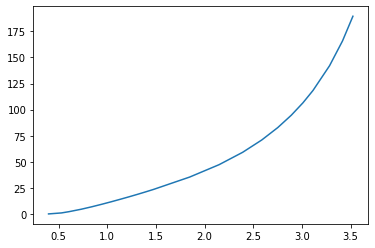

In [17]:
#Using Random Number Seed 1 Z stretch Small Scale
Tip_Num = 128;
Base_Num = 254;
Mobile_Num = 1996;

Tip_Forces = []
for i in range(0,len(Small_Forces),1):
    Tip_Force = Small_Forces[i]/Tip_Num;
    Tip_Forces.append(Tip_Force)
    #print('#fix             3 tip addforce',str(Tip_Force), '0 0') # For X
    #print('#fix             3 tip addforce 0 0 ', str(Tip_Force)) # For Z

#Unitless Force vs displacement Seed 1: Z direction
Force_Dp_1_Z = np.array([
    [181.696,Tip_Forces[0]],
    [198.956,Tip_Forces[1]],
    [208.834,Tip_Forces[2]],
    [225.462,Tip_Forces[3]],
    [239.673,Tip_Forces[4]],
    [252.777,Tip_Forces[5]],
    [265.276,Tip_Forces[6]], #50 nN
    [277.258,Tip_Forces[7]],
    [288.99,Tip_Forces[8]],
    [300.328,Tip_Forces[9]],
    [311.279,Tip_Forces[10]],
    [321.905,Tip_Forces[11]],
    [370.185,Tip_Forces[12]],
    [409.446,Tip_Forces[13]],
    [440.921,Tip_Forces[14]],
    [466.53,Tip_Forces[15]],
    [487.843,Tip_Forces[16]],
    [505.923,Tip_Forces[17]],
    [521.453,Tip_Forces[18]],
    [534.9,Tip_Forces[19]],
    [557.013,Tip_Forces[20]],
    [574.283,Tip_Forces[21]],
    [588.198,Tip_Forces[22]],
])

Force_Len_1_Z = [Force_Dp_1_Z[:,0]*dx,np.array(Small_Forces)*(1/(dt**2/dm/dx))]
Stress_Strain_1_Z = [(dx*Force_Dp_1_Z[:,0]-L_0)/L_0,np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross]

plt.plot(Stress_Strain_1_Z[0],Stress_Strain_1_Z[1])
for i in range(1,len(Stress_Strain_1_Z[0]),1):
    stress = Stress_Strain_1_Z[0][i];
    strain = Stress_Strain_1_Z[1][i];
    print(str(stress),' ',str(strain))

0.4311000000000001   1.1826745562130185
0.5047769230769231   2.3602366863905346
0.628346153846154   4.733254437869826
0.7324384615384617   7.100307692307698
0.8414692307692309   9.467360946745568
0.934315384615385   11.833562130177523
1.0210230769230768   14.200615384615396
1.104553846153846   16.567668639053267
1.1847000000000003   18.934721893491137
1.2613461538461543   21.301775147929
1.334676923076923   23.66863905325444
1.6640538461538463   35.502958579881664
1.9369615384615388   47.33727810650888
2.1599000000000004   59.17159763313611
2.3410538461538466   71.00591715976333
2.4889615384615382   82.84023668639057
2.611038461538462   94.67455621301777
2.7169769230769236   106.50887573964499
2.8077615384615386   118.34319526627222
2.9558923076923076   142.01183431952666
3.0724769230769233   165.68047337278114
3.1717923076923076   189.34911242603553


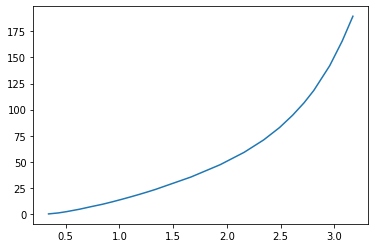

In [18]:
#Using Random Number Seed 1 X stretch
Tip_Num = 96;
Base_Num = 207;
Mobile_Num = 2043;

Tip_Forces = []
for i in range(0,len(Small_Forces),1):
    Tip_Force = Small_Forces[i]/Tip_Num;
    #print('#fix             7 tip addforce',str(Tip_Force), '0 0')
    Tip_Forces.append(Tip_Force)



#Unitless Force vs displacement Seed 1: X direction
Force_Dp_1_X = np.array([
    [174.188,Tip_Forces[0]],
    [186.043,Tip_Forces[1]],
    [195.621,Tip_Forces[2]],
    [211.685,Tip_Forces[3]],
    [225.217,Tip_Forces[4]],
    [239.391,Tip_Forces[5]],
    [251.461,Tip_Forces[6]],    # 50 nN
    [262.733,Tip_Forces[7]],
    [273.592,Tip_Forces[8]],
    [284.011,Tip_Forces[9]],
    [293.975,Tip_Forces[10]],
    [303.508,Tip_Forces[11]],
    [346.327,Tip_Forces[12]],
    [381.805,Tip_Forces[13]],
    [410.787,Tip_Forces[14]],
    [434.337,Tip_Forces[15]],
    [453.565,Tip_Forces[16]],
    [469.435,Tip_Forces[17]],
    [483.207,Tip_Forces[18]],
    [495.009,Tip_Forces[19]],
    [514.266,Tip_Forces[20]],
    [529.422,Tip_Forces[21]],
    [542.333,Tip_Forces[22]],
])

Force_Len_1_X = [Force_Dp_1_X[:,0]*dx,np.array(Small_Forces)*(1/(dt**2/dm/dx))]
Stress_Strain_1_X = [(dx*Force_Dp_1_X[:,0]-L_0)/L_0,np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross]

#print(Stress_Strain_1_X)

plt.plot(Stress_Strain_1_X[0],Stress_Strain_1_X[1])
for i in range(1,len(Stress_Strain_1_X[0]),1):
    stress = Stress_Strain_1_X[0][i];
    strain = Stress_Strain_1_X[1][i];
    print(str(stress),' ',str(strain))

0.4271461538461538   1.1826745562130185
0.5215692307692309   2.3602366863905346
0.6506615384615386   4.733254437869826
0.7588076923076925   7.100307692307698
0.8663307692307691   9.467360946745568
0.9625769230769231   11.833562130177523
1.052446153846154   14.200615384615396
1.1364384615384617   16.567668639053267
1.2168230769230772   18.934721893491137
1.2939538461538462   21.301775147929
1.3684461538461543   23.66863905325444
1.7018923076923078   35.502958579881664
1.9775153846153846   47.33727810650888
2.205230769230769   59.17159763313611
2.393146153846154   71.00591715976333
2.549438461538462   82.84023668639057
2.680130769230769   94.67455621301777
2.789961538461538   106.50887573964499
2.883123076923077   118.34319526627222
3.0303999999999998   142.01183431952666
3.139361538461538   165.68047337278114
3.2222153846153847   189.34911242603553


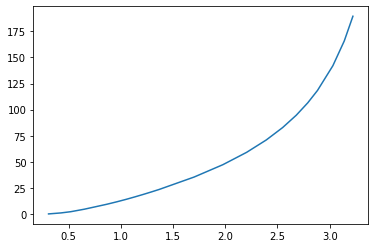

In [19]:
#Using Random Number Seed 1 Y stretch Small Scale
Tip_Num = 155;
Base_Num = 206;
Mobile_Num = 2044;

Tip_Forces = []
for i in range(0,len(Small_Forces),1):
    Tip_Force = Small_Forces[i]/Tip_Num;
    Tip_Forces.append(Tip_Force)
    #print('#fix             3 tip addforce',str(Tip_Force), '0 0') # For X
    #print('#fix             3 tip addforce 0 ',str(Tip_Force),' 0') # For Y
    #print('#fix             3 tip addforce 0 0 ', str(Tip_Force)) # For Z

#Unitless Force vs displacement Seed 1: Z direction
Force_Dp_1_Z = np.array([
    [170.119,Tip_Forces[0]],
    [185.529,Tip_Forces[1]],
    [197.804,Tip_Forces[2]],
    [214.586,Tip_Forces[3]],
    [228.645,Tip_Forces[4]],
    [242.623,Tip_Forces[5]],
    [255.135,Tip_Forces[6]], #50 nN
    [266.818,Tip_Forces[7]],
    [277.737,Tip_Forces[8]],
    [288.187,Tip_Forces[9]],
    [298.214,Tip_Forces[10]],
    [307.898,Tip_Forces[11]],
    [351.246,Tip_Forces[12]],
    [387.077,Tip_Forces[13]],
    [416.68,Tip_Forces[14]],
    [441.109,Tip_Forces[15]],
    [461.427,Tip_Forces[16]],
    [478.417,Tip_Forces[17]],
    [492.695,Tip_Forces[18]],
    [504.806,Tip_Forces[19]],
    [523.952,Tip_Forces[20]],
    [538.117,Tip_Forces[21]],
    [548.888,Tip_Forces[22]],
])

Force_Len_1_Z = [Force_Dp_1_Z[:,0]*dx,np.array(Small_Forces)*(1/(dt**2/dm/dx))]
Stress_Strain_1_Z = [(dx*Force_Dp_1_Z[:,0]-L_0)/L_0,np.array(Small_Forces)*(1/(dt**2/dm/dx))/A_Cross]

plt.plot(Stress_Strain_1_Z[0],Stress_Strain_1_Z[1])
for i in range(1,len(Stress_Strain_1_Z[0]),1):
    stress = Stress_Strain_1_Z[0][i];
    strain = Stress_Strain_1_Z[1][i];
    print(str(stress),' ',str(strain))